# KMeans RFM Customer Segmentation

Exploratory analysis and training notebook for KMeans-based customer segmentation using **RFM** (Recency, Frequency, Monetary) features.

| | |
|---|---|
| **Dataset** | Olist E-commerce (2016–2018) |
| **Training period** | 2016-09-04 → 2017-02-28 |
| **Algorithm** | KMeans with RobustScaler |
| **Segments** | Champions · Potential · At Risk |

In [ ]:
from dotenv import load_dotenv
from os import getenv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import logging
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import yaml

log = logging.getLogger(__name__)

In [9]:
# import kmeans_service
import sys, os
sys.path.insert(0, os.path.abspath('../airflow-server'))
print(sys.path[0])
from plugins.services.kmeans_service import *

d:\FPTU_Education\olist-capstone-workspace\airflow-server


## 1. Configuration & Database Connection

Load training parameters from `contexts/kmeans_rfm_training.yaml` and connect to PostgreSQL via SQLAlchemy.

In [67]:
# Load configuration from YAML file
config = yaml.safe_load(open(sys.path[0] + r'\contexts\kmeans_rfm_training.yaml'))

training_schema = config['postgres']['training']['schema']
training_table = config['postgres']['training']['table']
start_date = config['postgres']['training']['start_date']
end_date = config['postgres']['training']['end_date']
snapshot_date = config['postgres']['training']['snapshot_date']
window_days = config['postgres']['training']['window_days']
n_clusters = config['postgres']['training']['n_clusters']
training_query = config['postgres']['training']['query']

# load environment variables
load_dotenv()
database = getenv("DATABASE")
user = getenv("USER")
password = getenv("PASSWORD")
host = getenv("HOST")
port = getenv("PORT")
supabase_url = getenv("SUPABASE_URL")
supabase_key = getenv("SUPABASE_KEY")

## 2. Data Extraction

Extract RFM features from the database for the training period.

| Feature | Description |
|---|---|
| **Recency** | Days since last purchase relative to `end_date` |
| **Frequency** | Number of distinct orders |
| **Monetary** | Total payment value (BRL) |

In [68]:
# Create engine and extract data
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')
df = extract_data(engine, training_query, start_date=start_date, end_date=end_date)
df.head()

,customer_unique_id,event_date,revenue
0,00115fc7123b5310cf6d3a3aa932699e,2017-01-21,76.11
1,002b4cd83fabaffaa475f78ea5ef3e08,2017-02-01,64.42
2,0032c76b20340da25249092a268ce66c,2016-10-06,144.94
3,0087eede471173af78d789df249c3a45,2017-02-16,151.11
4,008f3d5f45a11059239a5c452cd00006,2017-01-26,336.56


## 3. RFM Computation

Compute **Recency**, **Frequency**, and **Monetary** features per customer from raw order data.

| Feature | Window | Description |
|---|---|---|
| **Recency** | Full period | Days since last purchase relative to `snapshot_date` |
| **Frequency** | Last 30 days | Number of orders within the 30-day window |
| **Monetary** | Last 30 days | Total revenue within the 30-day window |

Customers who bought outside the 30-day window receive Frequency = 0, Monetary = 0 — they become the **Cooling Down** and **Dormant** segments.

In [69]:
print(f"Rows loaded: {len(df):,}")
print(f"Unique users: {df['customer_unique_id'].nunique():,}")
print(f"Date range: {df['event_date'].min()} → {df['event_date'].max()}")

Rows loaded: 2,748
Unique users: 2,734
Date range: 2016-09-04 → 2017-02-28


In [70]:
window_start = snapshot_date - pd.Timedelta(days=window_days)
df_window = df[df['event_date'] >= window_start].copy()

print(f"Snapshot date: {snapshot_date}")
print(f"Window start: {window_start}")
print(f"Window end: {snapshot_date}")

Snapshot date: 2017-02-28
Window start: 2017-01-29
Window end: 2017-02-28


In [72]:
# All unique users in the full dataset
all_users = df[['customer_unique_id']].drop_duplicates()

# Recency
recency_df = (
    df
    .groupby('customer_unique_id')['event_date']
    .max()
    .reset_index()
    .rename(columns={'event_date': 'last_order_date'})
)
snapshot_date = pd.to_datetime(snapshot_date)
recency_df['last_order_date'] = pd.to_datetime(recency_df['last_order_date'])
recency_df['recency'] = (snapshot_date - recency_df['last_order_date']).dt.days

# Frequency 30d
rfm_30d = (
    df_window
    .groupby('customer_unique_id')
    .agg(
        freq_30d=('event_date', 'count'),
        monetary_30d=('revenue', 'sum')
    )
)

# final df
rfm = (
    all_users
    .merge(recency_df[['customer_unique_id', 'recency']], on='customer_unique_id', how='left')
    .merge(rfm_30d, on='customer_unique_id', how='left')
)

# fillna
rfm['freq_30d'] = rfm['freq_30d'].fillna(0).astype(int)
rfm['monetary_30d'] = rfm['monetary_30d'].fillna(0.0)

rfm['snapshot_date'] = snapshot_date.date()

print(f"RFM users total: {len(rfm):,}")
print(f"Users với freq=0: {(rfm['freq_30d'] == 0).sum():,} ({(rfm['freq_30d'] == 0).mean():.1%})")
rfm.head(10)

RFM users total: 2,734
Users với freq=0: 896 (32.8%)


,customer_unique_id,recency,freq_30d,monetary_30d,snapshot_date
0,00115fc7123b5310cf6d3a3aa932699e,38,0,0.0,2017-02-28
1,002b4cd83fabaffaa475f78ea5ef3e08,27,1,64.42,2017-02-28
2,0032c76b20340da25249092a268ce66c,145,0,0.0,2017-02-28
3,0087eede471173af78d789df249c3a45,12,1,151.11,2017-02-28
4,008f3d5f45a11059239a5c452cd00006,33,0,0.0,2017-02-28
5,012b8001e47392df808a454083a74b74,18,1,98.84,2017-02-28
6,012e12f54f6e73b1faba89a119dab849,30,1,105.74,2017-02-28
7,01469c41b00bb21cd01d2104b8e81384,17,1,111.01,2017-02-28
8,016feebfaba953a2456d3a063b8eb8ef,15,1,62.83,2017-02-28
9,01838e7d69d87bd8ff2b6ff06789adfb,38,0,0.0,2017-02-28


In [74]:
print(rfm[['recency', 'freq_30d', 'monetary_30d']].describe().round(2))
print(f"\nNull check:")
print(rfm.isnull().sum())

       recency  freq_30d
count  2734.00   2734.00
mean     34.46      0.68
std      39.82      0.48
min       0.00      0.00
25%      13.00      0.00
50%      23.00      1.00
75%      34.00      1.00
max     177.00      2.00

Null check:
customer_unique_id    0
recency               0
freq_30d              0
monetary_30d          0
snapshot_date         0
dtype: int64


## 4. Feature Engineering

- Apply `log1p` transform to both `freq_30d` and `monetary_30d` to reduce right skew
- Scale all 3 features using `RobustScaler` (median + IQR) — robust to outliers
- Visualise distributions before scaling to verify transformation quality

In [75]:
rfm['log_freq_30d'] = np.log1p(rfm['freq_30d'])
rfm['log_monetary_30d'] = np.log1p(rfm['monetary_30d'].astype(float))

features = ['recency', 'log_freq_30d', 'log_monetary_30d']
x = rfm[features].values

print(f"Features used: {features}")
print(f"Feature matrix shape: {x.shape}")
print(x[:5])  # Print first 5 rows

Features used: ['recency', 'log_freq_30d', 'log_monetary_30d']
Feature matrix shape: (2734, 3)
[[ 38.           0.           0.        ]
 [ 27.           0.69314718   4.18082802]
 [145.           0.           0.        ]
 [ 12.           0.69314718   5.02460394]
 [ 33.           0.           0.        ]]


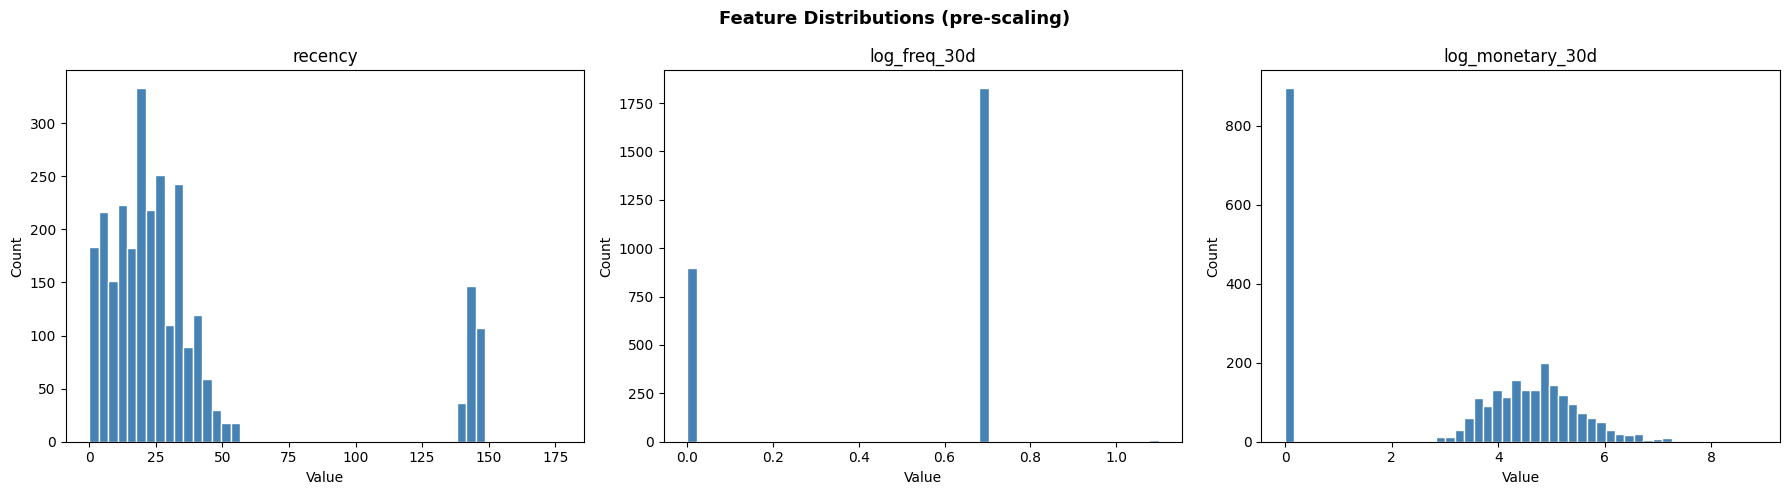

In [76]:
# distribution of features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(features):
    axes[i].hist(rfm[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Feature Distributions (pre-scaling)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [77]:
# scale features
scaler = RobustScaler()
x_scaled = scaler.fit_transform(x)

print("Scaled feature stats:")
print(pd.DataFrame(x_scaled, columns=features).describe().round(3))

Scaled feature stats:
        recency  log_freq_30d  log_monetary_30d
count  2734.000      2734.000          2734.000
mean      0.546        -0.326            -0.190
std       1.896         0.472             0.470
min      -1.095        -1.000            -0.833
25%      -0.476        -1.000            -0.833
50%       0.000         0.000             0.000
75%       0.524         0.000             0.167
max       7.333         0.585             0.961


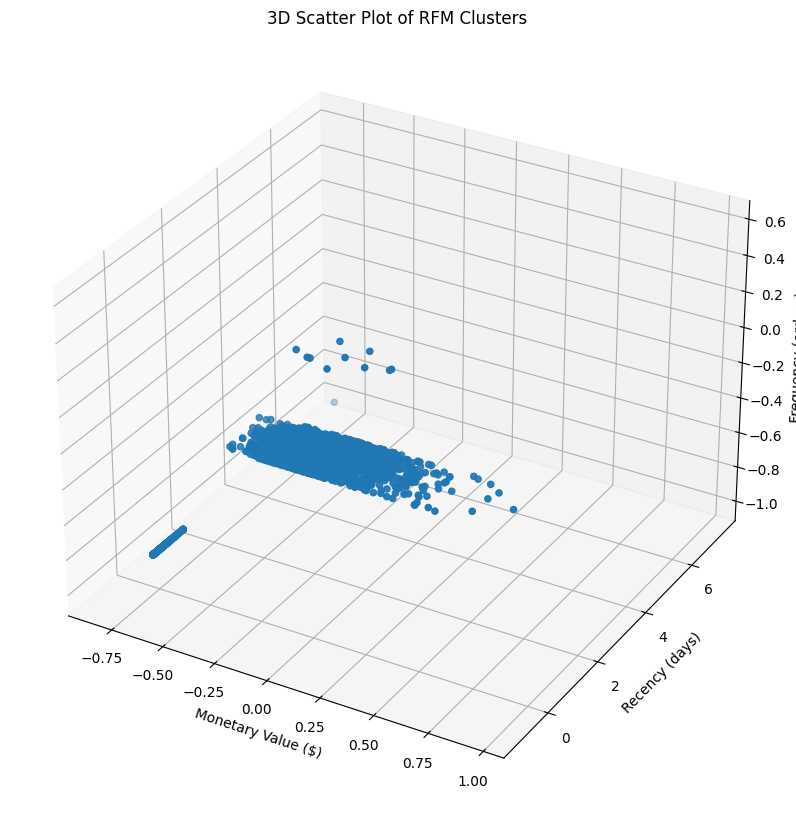

In [78]:
# 3D Scatter Plot of RFM Clusters
df_scaled = pd.DataFrame(x_scaled, columns=['recency', 'log_freq_30d', 'log_monetary_30d'])

fig = plt.figure(figsize=(10, 18))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled['log_monetary_30d'].astype(float),
    df_scaled['recency'].astype(float),
    df_scaled['log_freq_30d'].astype(float)
)

ax.set_xlabel('Monetary Value ($)')
ax.set_ylabel('Recency (days)')
ax.set_zlabel('Frequency (orders)')

ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

## 5. Finding Optimal k — Elbow Method & Silhouette Score

Evaluate `k` from 2 to 7 on **scaled data** using two metrics:

| Metric | What to look for |
|---|---|
| **Inertia (Elbow)** | Point where inertia starts decreasing slowly — the "elbow" |
| **Silhouette Score** | Higher = better cluster separation (range: -1 to 1) |

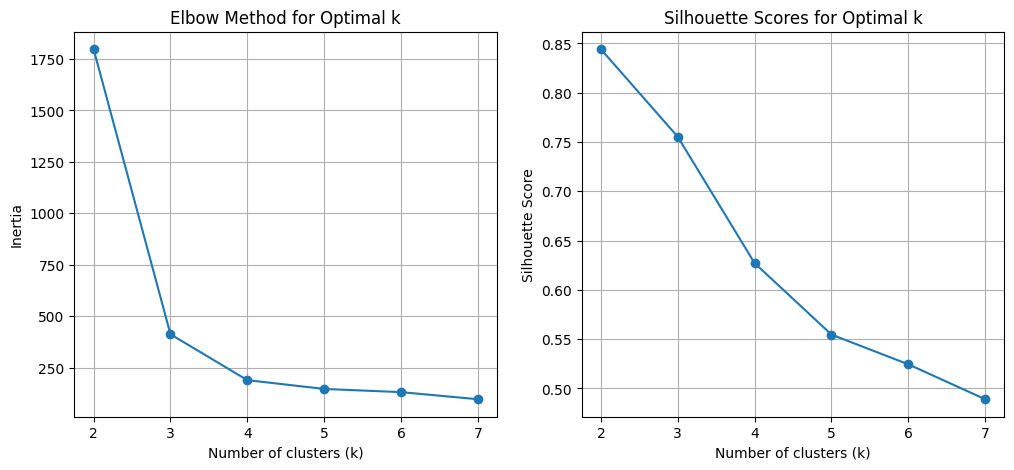

In [79]:
# Elbow Method
from sklearn.cluster import KMeans

inertia = []
silhouette_scores = []
for k in range (2, 8):
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)

    # Append inertia
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score
    sil = silhouette_score(x_scaled, labels)
    silhouette_scores.append(sil)

# Plot inertia
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 8), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(2, 8), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()

plt.show()

## 6. Model Training

Train KMeans with `n_clusters=3` on scaled RFM data.  
Segment labels are assigned based on centroid **recency rank** — recency is the strongest signal in this low-frequency dataset.

| Segment | Recency | Freq 30d | Monetary 30d |
|---|---|---|---|
| **active_buyers** | low (recent) | > 0 | > 0 |
| **cooling_down** | medium | 0 | 0 |
| **dormant** | high (inactive) | 0 | 0 |

In [80]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
labels = kmeans.fit_predict(x_scaled)
rfm['cluster'] = labels
final_silhouette = silhouette_score(x_scaled, rfm['cluster'], sample_size=5000)
print(f"Final silhouette score for k={n_clusters}: {final_silhouette:.4f}")
print(f"Cluster distribution:")
print(rfm['cluster'].value_counts().sort_index())

Final silhouette score for k=3: 0.7553
Cluster distribution:
cluster
0     605
1     291
2    1838
Name: count, dtype: int64


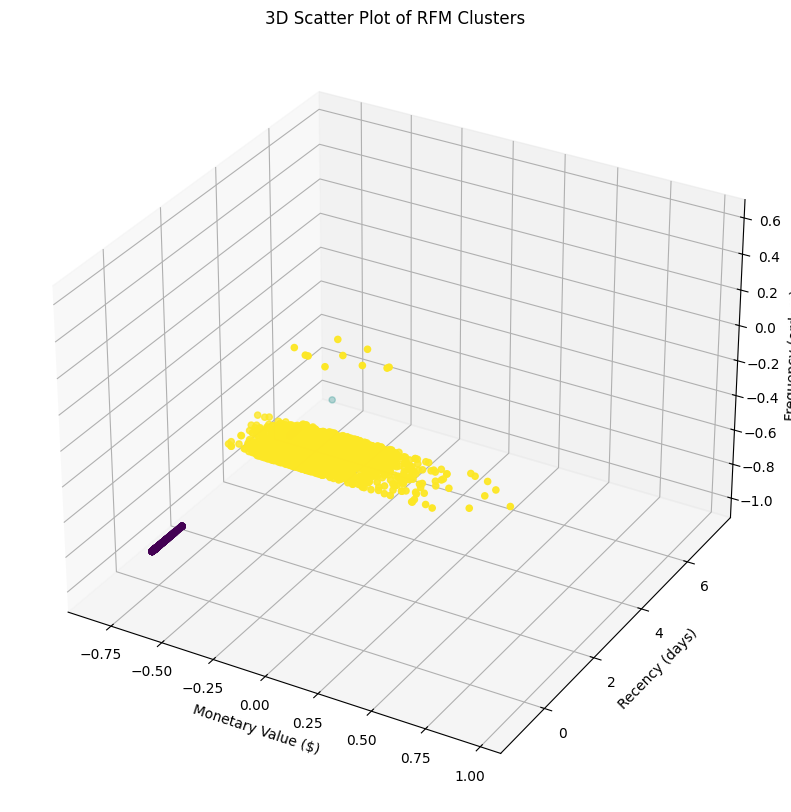

In [81]:
# 3D Scatter Plot of RFM Clusters
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled['log_monetary_30d'].astype(float),
    df_scaled['recency'].astype(float),
    df_scaled['log_freq_30d'].astype(float),
    c=rfm['cluster'], cmap='viridis', marker='o'
)

ax.set_xlabel('Monetary Value ($)')
ax.set_ylabel('Recency (days)')
ax.set_zlabel('Frequency (orders)')
ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

## 7. Cluster Analysis & Segment Profiles

Profile each cluster on raw RFM dimensions and map to business segment names.

| Segment | Recency | Freq 30d | Monetary 30d | MKT Strategy |
|---|---|---|---|---|
| **active_buyers** | Low (~17d) | 1 | ~110 BRL | Retention · Upsell · Loyalty |
| **cooling_down** | Medium (~36d) | 0 | 0 | Win-back · Limited-time offer |
| **dormant** | High (~145d) | 0 | 0 | Last-chance discount · Suppress |

In [82]:
profile = (
    rfm
    .groupby('cluster')
    .agg(
        n_user=('customer_unique_id', 'count'),
        recency_med=('recency', 'median'),
        freq_med=('freq_30d', 'median'),
        monetary_med=('monetary_30d', 'median'),
        monetary_avg = ('monetary_30d', 'mean'),
    ).round(2)
)
profile['distribution_user(%)'] = (profile['n_user'] / len(rfm) * 100).round(2)
print(profile.to_string())

         n_user  recency_med  freq_med monetary_med monetary_avg  distribution_user(%)
cluster                                                                               
0           605         36.0       0.0          0.0          0.0                 22.13
1           291        145.0       0.0          0.0          0.0                 10.64
2          1838         17.0       1.0       110.25   171.589793                 67.23


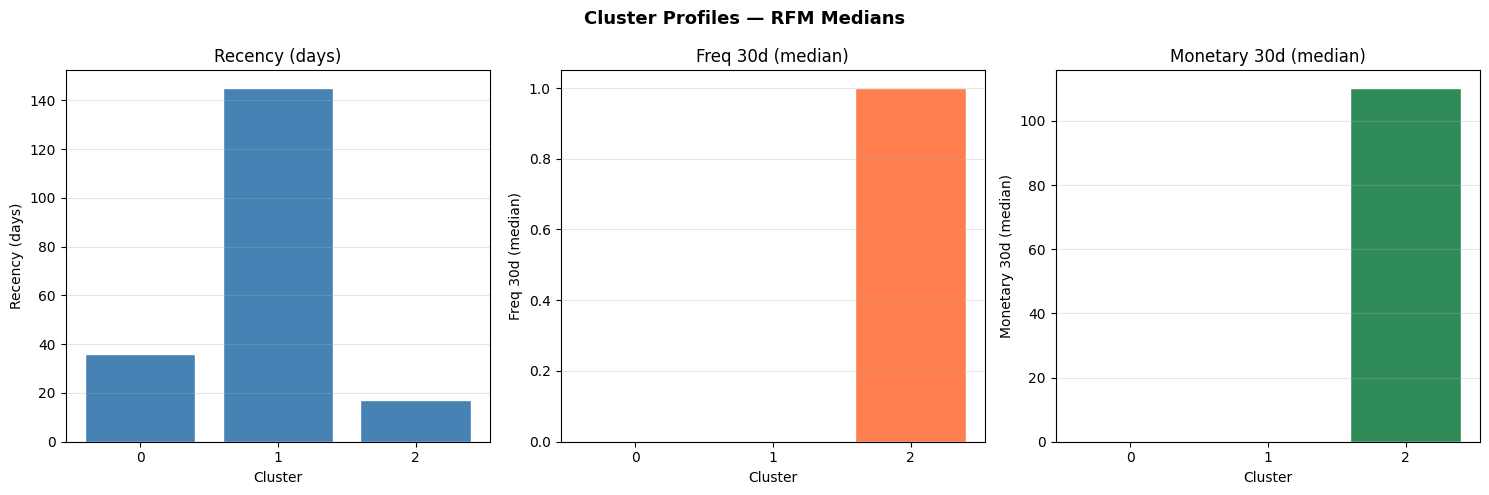

In [83]:
# visualize cluster profiles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ('recency_med',  'Recency (days)',    'steelblue'),
    ('freq_med',     'Freq 30d (median)', 'coral'),
    ('monetary_med', 'Monetary 30d (median)', 'seagreen'),
]
for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(profile.index.astype(str), profile[col], color=color, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Profiles — RFM Medians', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [84]:
rfm.head()

,customer_unique_id,recency,freq_30d,monetary_30d,snapshot_date,log_freq_30d,log_monetary_30d,cluster
0,00115fc7123b5310cf6d3a3aa932699e,38,0,0.0,2017-02-28,0.000000,0.000000,0
1,002b4cd83fabaffaa475f78ea5ef3e08,27,1,64.42,2017-02-28,0.693147,4.180828,2
2,0032c76b20340da25249092a268ce66c,145,0,0.0,2017-02-28,0.000000,0.000000,1
3,0087eede471173af78d789df249c3a45,12,1,151.11,2017-02-28,0.693147,5.024604,2
4,008f3d5f45a11059239a5c452cd00006,33,0,0.0,2017-02-28,0.000000,0.000000,0


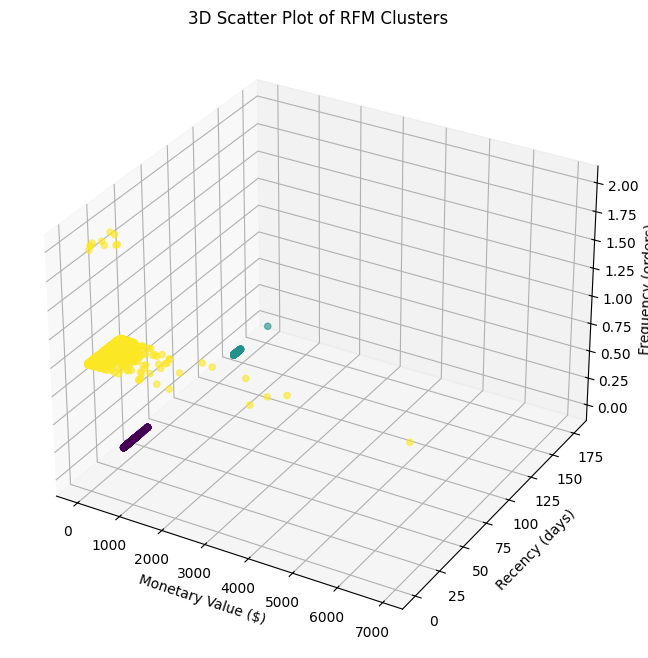

In [86]:
# 3D Scatter Plot of RFM Clusters
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm['monetary_30d'].astype(float),
    rfm['recency'].astype(float),
    rfm['freq_30d'],
    c=rfm['cluster'], cmap='viridis', alpha=0.6
)

ax.set_xlabel('Monetary Value ($)')
ax.set_ylabel('Recency (days)')
ax.set_zlabel('Frequency (orders)')

ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()